In [272]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [273]:
nvda = yf.download('NVDA', start='2020-01-01', end=datetime.now().strftime('%Y-%m-%d'))
nvda = nvda.reset_index()
nvda['Date'] = pd.to_datetime(nvda['Date'])
nvda = nvda.sort_values('Date')
nvda.columns = nvda.columns.droplevel(1)
nvda['Ticker'] = 'NVDA'
nvda = nvda.set_index('Date')
nvda.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Ticker
Date,,,,,,
2020-01-02,5.970755,5.970755,5.891364,5.941885,237536000,NVDA
2020-01-03,5.875188,5.918990,5.826159,5.851047,205384000,NVDA
2020-01-06,5.899825,5.905051,5.755726,5.781858,262636000,NVDA
2020-01-07,5.971253,6.017046,5.883151,5.928197,314856000,NVDA
2020-01-08,5.982451,6.023765,5.926952,5.967021,277108000,NVDA


In [274]:
X = nvda.drop(['Ticker', 'Close'], axis=1)
y = nvda['Close']

In [275]:
X.columns

Index(['High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [276]:
split_idx = int(len(nvda) * 0.8)

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]

X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

In [277]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [278]:
xg_model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.001, 
    random_state=42, 
    booster='gbtree', 
    n_jobs=-1, 
    max_depth = 20,
    min_child_weight = 5

    )
xg_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.001, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=20, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [279]:
xg_pred = xg_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, xg_pred)
mse = mean_squared_error(y_test, xg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, xg_pred)

# 3. Print the evaluation report
print("===== XGBoost Regressor Evaluation =====")
print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score (Variance Explained):  {r2:.4f}")

===== XGBoost Regressor Evaluation =====
Mean Absolute Error (MAE):     68.3642
Root Mean Squared Error (RMSE): 73.1665
R2 Score (Variance Explained):  -4.4739


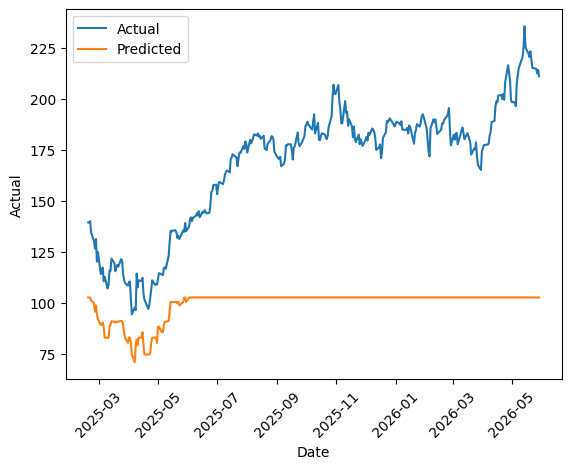

In [280]:
xg_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': xg_pred
}, index=y_test.index).reset_index()

sns.lineplot(data=xg_results, x='Date', y='Actual', label="Actual")
sns.lineplot(data=xg_results, x='Date', y='Predicted', label="Predicted")
plt.xticks(rotation=45)
plt.show()

In [281]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [282]:
rf_pred = rf_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_pred)

# 3. Print the evaluation report
print("===== Random Forest Regressor Evaluation =====")
print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score (Variance Explained):  {r2:.4f}")

===== Random Forest Regressor Evaluation =====
Mean Absolute Error (MAE):     27.2899
Root Mean Squared Error (RMSE): 33.7403
R2 Score (Variance Explained):  -0.1640


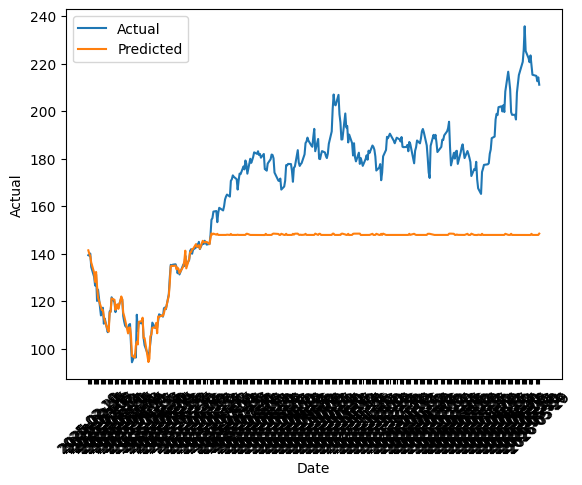

In [283]:
rf_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': rf_pred
}, index=y_test.index).reset_index()

sns.lineplot(data=rf_results, x='Date', y='Actual', label="Actual")
sns.lineplot(data=rf_results, x='Date', y='Predicted', label="Predicted")
plt.xticks(rf_results['Date'].values, rotation=45)
plt.show()

In [303]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1288, 4)
(322, 4)


In [335]:
timesteps = 10  # use last 10 days instead of 1

# Rebuild sequences
def create_sequences(X, y, timesteps):
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X[i:i+timesteps])
        ys.append(y[i+timesteps])
    return np.array(Xs), np.array(ys)

In [336]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

# Reshape for LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0],  1, X_test_scaled.shape[1]))

X_train_lstm, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, timesteps)
X_test_lstm,  y_test_seq  = create_sequences(X_test_scaled,  y_test_scaled,  timesteps)

In [337]:
input_shape=(timesteps, X_train_scaled.shape[1])

In [338]:
lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    Dropout(0.2),

    LSTM(64, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

lstm_model.fit(
    X_train_lstm, y_train_scaled,   # ← scaled y
    epochs=50,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/50


c:\Users\raeve\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0074 - mae: 0.0557 - val_loss: 0.0020 - val_mae: 0.0357
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 3.2016e-04 - mae: 0.0131 - val_loss: 0.0054 - val_mae: 0.0599
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 2.2948e-04 - mae: 0.0108 - val_loss: 0.0090 - val_mae: 0.0801
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.0829e-04 - mae: 0.0097 - val_loss: 0.0093 - val_mae: 0.0817
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 1.8080e-04 - mae: 0.0095 - val_loss: 0.0103 - val_mae: 0.0859
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.8540e-04 - mae: 0.0092 - val_loss: 0.0222 - val_mae: 0.1343
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 1.6250e-04 - mae: 0.0090 - val_loss: 0.0212 - val_mae: 0.1281
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.8754e-04 - mae: 0.0097 - val_loss: 0.0227 - val_mae: 0.1350
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/s

In [339]:
lstm_pred_scaled = lstm_model.predict(X_test_lstm)
lstm_pred = scaler_y.inverse_transform(lstm_pred_scaled)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


In [340]:
lstm_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': lstm_pred.flatten()
}, index=y_test.index).reset_index()

ValueError: Length of values (312) does not match length of index (322)

In [ ]:
lstm_results

,Date,Actual,Predicted
0,2025-02-18,139.354340,136.371964
1,2025-02-19,139.184402,134.904770
2,2025-02-20,140.064117,134.657150
3,2025-02-21,134.385956,133.989182
4,2025-02-24,130.237335,130.657211
...,...,...,...
317,2026-05-22,215.330002,209.062698
318,2026-05-26,214.860001,206.190918
319,2026-05-27,212.600006,203.271118
320,2026-05-28,214.250000,203.718323


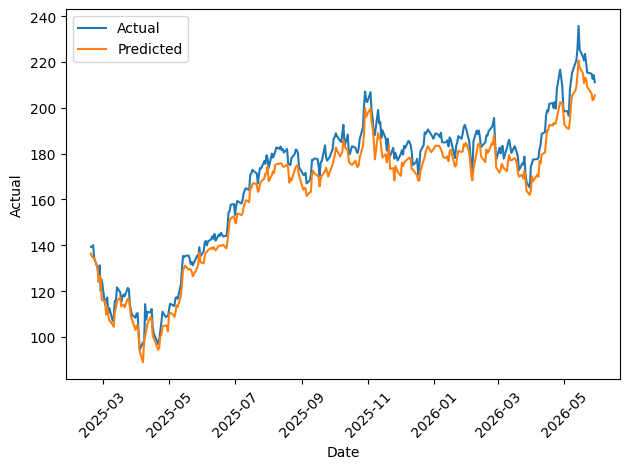

In [ ]:
sns.lineplot(data=lstm_results, x='Date', y='Actual',    label="Actual")
sns.lineplot(data=lstm_results, x='Date', y='Predicted', label="Predicted")

# Let matplotlib auto-select ticks instead of plotting every date
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()